In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [ ]:
# 1. Tải dữ liệu
df = pd.read_csv("/content/df_cleaned.csv")
df.head()

,now,published_at,price,house_type,size,property_legal_document,rooms,toilets,furnishing_sell,floors
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,7.95,"Nhà ngõ, hẻm",34.0,Đã có sổ,3.0,4.0,Nội thất cao cấp,5.0
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,13.80,"Nhà ngõ, hẻm",65.0,Đã có sổ,5.0,4.0,Nội thất đầy đủ,5.0
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,11.50,"Nhà ngõ, hẻm",44.0,Đã có sổ,4.0,3.0,Nội thất đầy đủ,3.0
3,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7.00,"Nhà ngõ, hẻm",38.0,Đã có sổ,3.0,3.0,Nội thất đầy đủ,5.0
4,2025-10-03T23:43:33.133247,Cập nhật 4 ngày trước,5.00,"Nhà ngõ, hẻm",32.0,Đã có sổ,3.0,4.0,Nội thất đầy đủ,4.0


In [ ]:
categorical_cols = ['property_legal_document', 'furnishing_sell','house_type']
le = LabelEncoder()
actual_price=df['price']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df['price']=actual_price
df

,now,published_at,price,house_type,size,property_legal_document,rooms,toilets,furnishing_sell,floors
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,7.95,0.225988,-0.562924,0.300019,-0.510086,0.313447,-0.872476,0.304179
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,13.80,0.225988,2.151667,0.300019,0.826286,0.313447,0.596524,0.304179
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,11.50,0.225988,0.312751,0.300019,0.158100,-0.661982,0.596524,-2.413877
3,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7.00,0.225988,-0.212654,0.300019,-0.510086,-0.661982,0.596524,0.304179
4,2025-10-03T23:43:33.133247,Cập nhật 4 ngày trước,5.00,0.225988,-0.738058,0.300019,-0.510086,0.313447,0.596524,-1.054849
...,...,...,...,...,...,...,...,...,...,...
1246,2025-10-04T12:46:06.176375,Cập nhật 9 ngày trước,8.35,0.225988,0.400318,0.300019,0.158100,0.313447,-0.872476,0.304179
1247,2025-10-04T12:46:09.347694,Cập nhật 9 ngày trước,7.90,0.225988,-0.387789,0.300019,0.158100,0.313447,0.596524,-1.054849
1248,2025-10-04T12:46:10.663161,Cập nhật 9 ngày trước,12.10,0.225988,-0.125086,0.300019,-0.510086,2.264304,-0.872476,1.663207
1249,2025-10-04T12:46:19.298759,Cập nhật 9 ngày trước,7.65,0.225988,0.137616,0.300019,-0.510086,0.313447,0.596524,0.304179


In [ ]:

y = df['price']
X = df.drop(columns=['price', 'now', 'published_at'])

In [ ]:
y.head()

,price
0,7.95
1,13.80
2,11.50
3,7.00
4,5.00


In [ ]:
X.head()

,house_type,size,property_legal_document,rooms,toilets,furnishing_sell,floors
0,0.225988,-0.562924,0.300019,-0.510086,0.313447,-0.872476,0.304179
1,0.225988,2.151667,0.300019,0.826286,0.313447,0.596524,0.304179
2,0.225988,0.312751,0.300019,0.158100,-0.661982,0.596524,-2.413877
3,0.225988,-0.212654,0.300019,-0.510086,-0.661982,0.596524,0.304179
4,0.225988,-0.738058,0.300019,-0.510086,0.313447,0.596524,-1.054849


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

# Xem tỉ lệ phương sai
import numpy as np
np.cumsum(pca.explained_variance_ratio_)


array([0.29866786, 0.46648524, 0.61465449, 0.75418555])

In [ ]:
X_pca

array([[ 0.01183901, -0.71145798, -0.47950197, -0.91962983],
       [ 0.98630354,  1.8220782 ,  0.83128581,  0.15640355],
       [-0.82428708,  0.11090865, -0.28354951,  1.48076334],
       ...,
       [ 1.62942407, -0.5008597 , -0.05960697, -1.62883522],
       [ 0.20434977, -0.29801016,  0.46561713,  0.16807588],
       [-0.46130668, -1.67880103,  0.30153721,  0.26830436]])

In [ ]:
# 3. Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [ ]:

# 4. Huấn luyện mô hình Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:

# 5. Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

In [ ]:
# 6. Đánh giá hiệu suất mô hình
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² = {r2:.4f}, RMSE = {rmse:.6f}")

R² = 0.4724, RMSE = 2.347878


In [ ]:
# 6. Lưu mô hình lại
joblib.dump(model, "linear_regression_model.pkl")
print("✅ Đã lưu mô hình vào file 'linear_regression_model.pkl'")

✅ Đã lưu mô hình vào file 'linear_regression_model.pkl'


In [ ]:
# 7.  Load mô hình đã lưu để kiểm tra
loaded_model = joblib.load("linear_regression_model.pkl")
print(" Đã load mô hình thành công")

 Đã load mô hình thành công


In [ ]:
# 8. Dự đoán giá nhà trên toàn bộ dữ liệu
df['predicted_price'] = loaded_model.predict(X_pca)
df

,now,published_at,price,house_type,size,property_legal_document,rooms,toilets,furnishing_sell,floors,predicted_price
0,2025-10-03T23:43:10.208844,Cập nhật 7 ngày trước,7.95,0.225988,-0.562924,0.300019,-0.510086,0.313447,-0.872476,0.304179,7.360657
1,2025-10-03T23:43:15.172138,Cập nhật 7 ngày trước,13.80,0.225988,2.151667,0.300019,0.826286,0.313447,0.596524,0.304179,10.476405
2,2025-10-03T23:43:15.898229,Cập nhật 9 ngày trước,11.50,0.225988,0.312751,0.300019,0.158100,-0.661982,0.596524,-2.413877,6.781057
3,2025-10-03T23:43:33.032891,Cập nhật 9 ngày trước,7.00,0.225988,-0.212654,0.300019,-0.510086,-0.661982,0.596524,0.304179,6.642681
4,2025-10-03T23:43:33.133247,Cập nhật 4 ngày trước,5.00,0.225988,-0.738058,0.300019,-0.510086,0.313447,0.596524,-1.054849,6.499200
...,...,...,...,...,...,...,...,...,...,...,...
1246,2025-10-04T12:46:06.176375,Cập nhật 9 ngày trước,8.35,0.225988,0.400318,0.300019,0.158100,0.313447,-0.872476,0.304179,8.747418
1247,2025-10-04T12:46:09.347694,Cập nhật 9 ngày trước,7.90,0.225988,-0.387789,0.300019,0.158100,0.313447,0.596524,-1.054849,7.408734
1248,2025-10-04T12:46:10.663161,Cập nhật 9 ngày trước,12.10,0.225988,-0.125086,0.300019,-0.510086,2.264304,-0.872476,1.663207,9.593939
1249,2025-10-04T12:46:19.298759,Cập nhật 9 ngày trước,7.65,0.225988,0.137616,0.300019,-0.510086,0.313447,0.596524,0.304179,7.634708


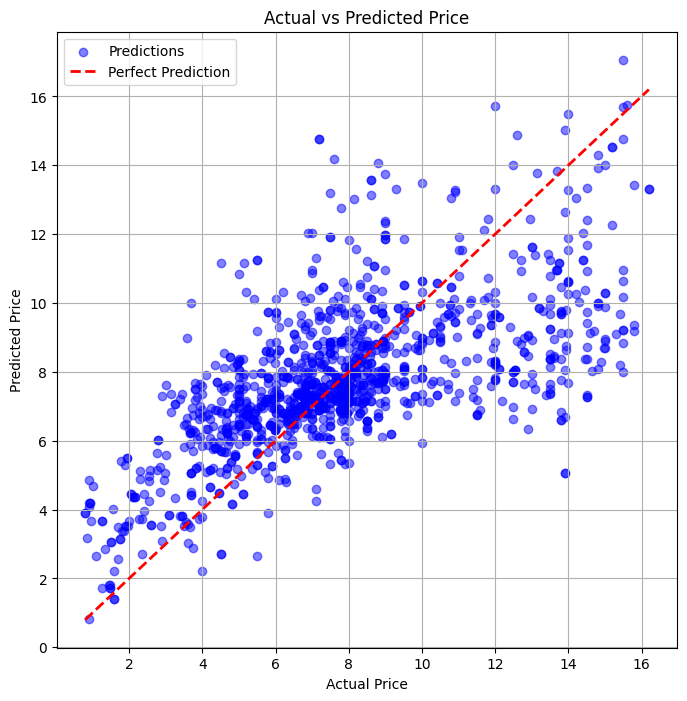

In [ ]:
import matplotlib.pyplot as plt

# Giả sử df có 2 cột: 'actual_price' và 'predicted_price'
y_actual = df['price']
y_pred = df['predicted_price']

plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.grid(True)
plt.show()
